<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Comprehensive_Stock_Market_Analysis_using_OHLC%2C_Volume%2C_Returns%2C_and_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
pip install pandas numpy matplotlib seaborn yfinance scikit-learn xgboost plotly

In [41]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [42]:
ticker = 'TSLA'

df = yf.download(
    ticker,
    start = '2020-01-01',
    end = '2026-05-01'
)

[*********************100%***********************]  1 of 1 completed


In [43]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1590 entries, 2020-01-02 to 2026-04-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1590 non-null   float64
 1   (High, TSLA)    1590 non-null   float64
 2   (Low, TSLA)     1590 non-null   float64
 3   (Open, TSLA)    1590 non-null   float64
 4   (Volume, TSLA)  1590 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.5 KB


In [45]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1590.000000,1590.000000,1590.000000,1590.000000,1.590000e+03
mean,245.704880,251.132737,240.077807,245.783850,1.179414e+08
std,101.710124,103.683810,99.815815,101.905265,7.609482e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,186.074997,189.412506,182.002499,185.484997,7.206345e+07
50%,239.128334,244.766670,234.021667,239.305000,9.715900e+07
75%,308.727509,314.495842,301.129997,308.200005,1.342137e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


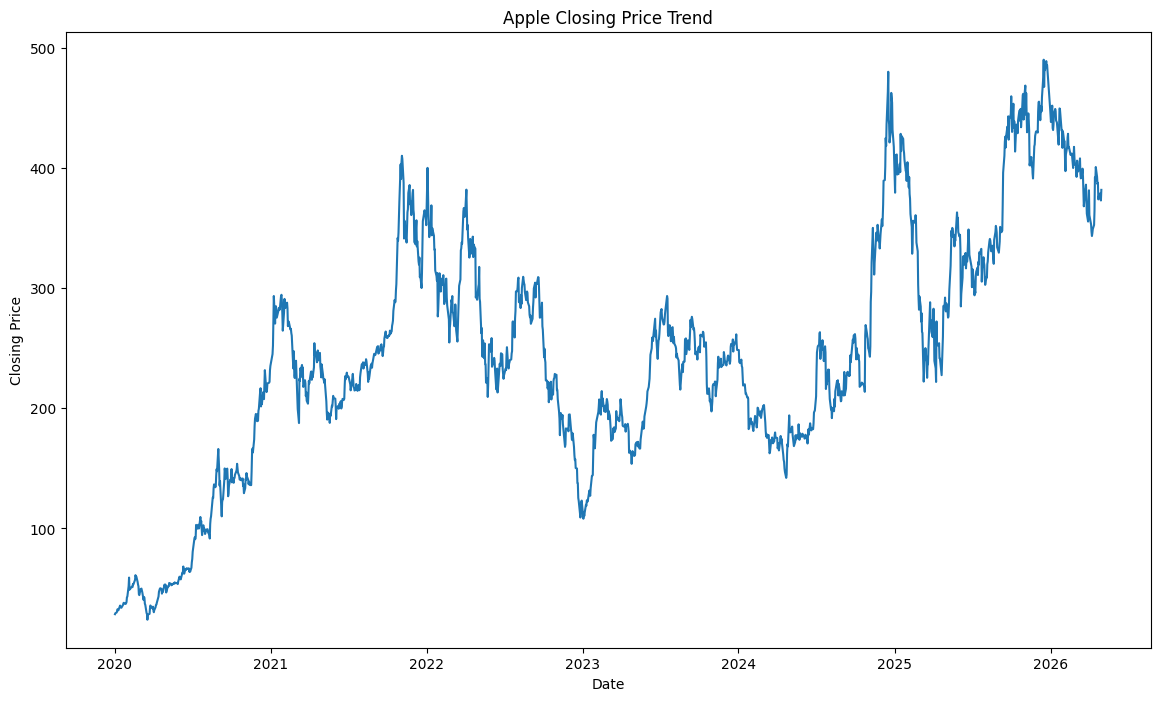

In [46]:
plt.figure(figsize=(14,8))

sns.lineplot(
    x = df.index,
    y = df['Close'].squeeze()
)

plt.title("Apple Closing Price Trend")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

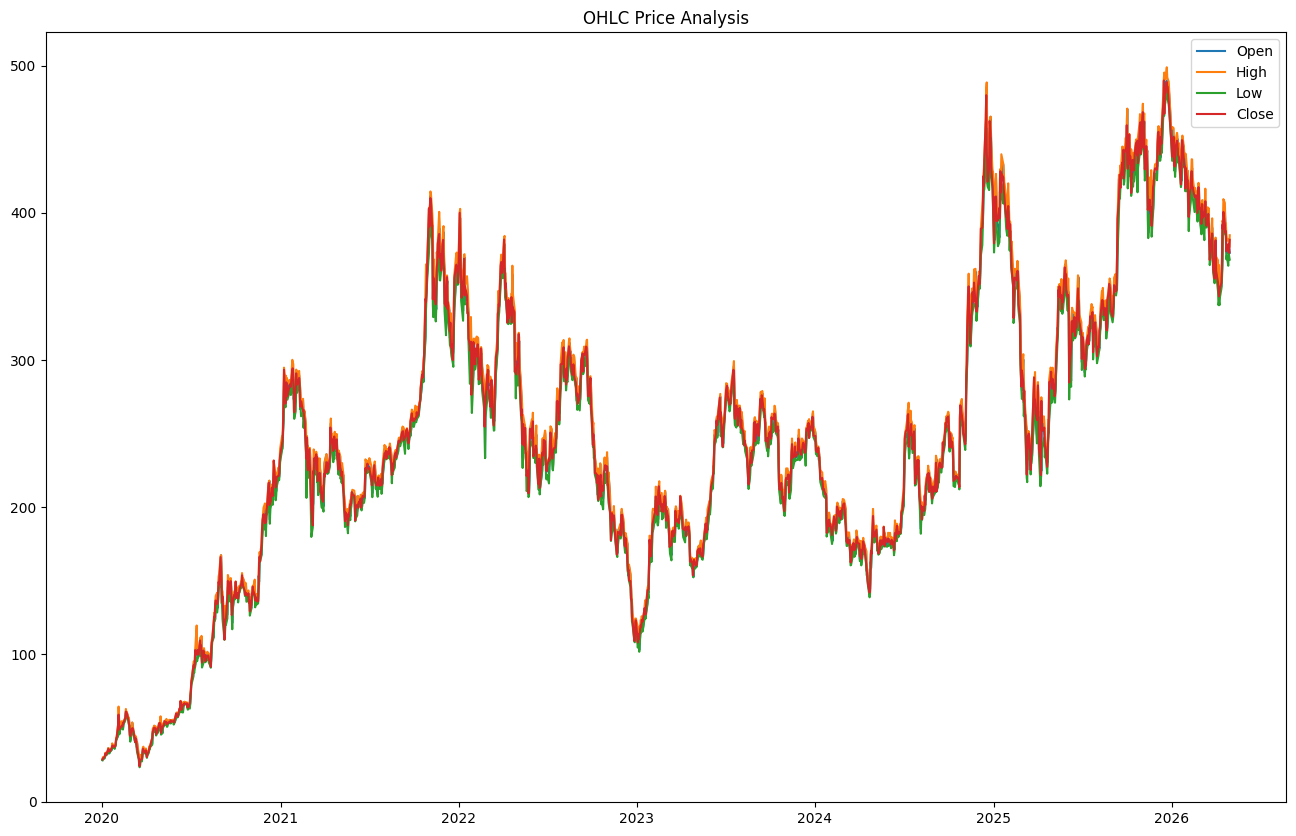

In [47]:
plt.figure(figsize=(16,10))

plt.plot(df['Open'],label='Open')

plt.plot(df['High'],label='High')

plt.plot(df['Low'],label='Low')

plt.plot(df['Close'], label='Close')

plt.legend()

plt.title('OHLC Price Analysis')

plt.show()

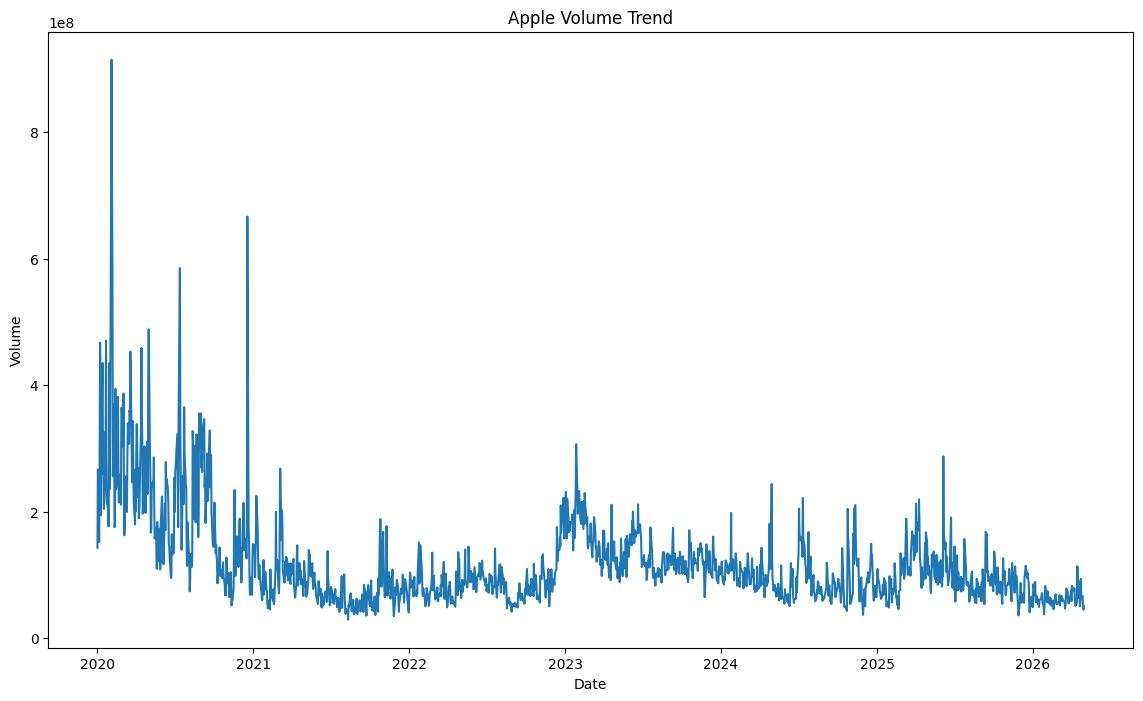

In [48]:
plt.figure(figsize=(14,8))

sns.lineplot(
    x = df.index,
    y = df['Volume'].squeeze()
)

plt.title('Apple Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

###High volume indicates:

###✅ Strong investor activity
###✅ Institutional participation
###✅ News impact

In [49]:
df['Daily Return'] = (
    df['Close'].pct_change()
)

###Returns are the MOST IMPORTANT concept in finance.

###Used in:

###Portfolio analytics
###Risk management
###Trading
###Performance measurement

Text(0, 0.5, 'Frequency')

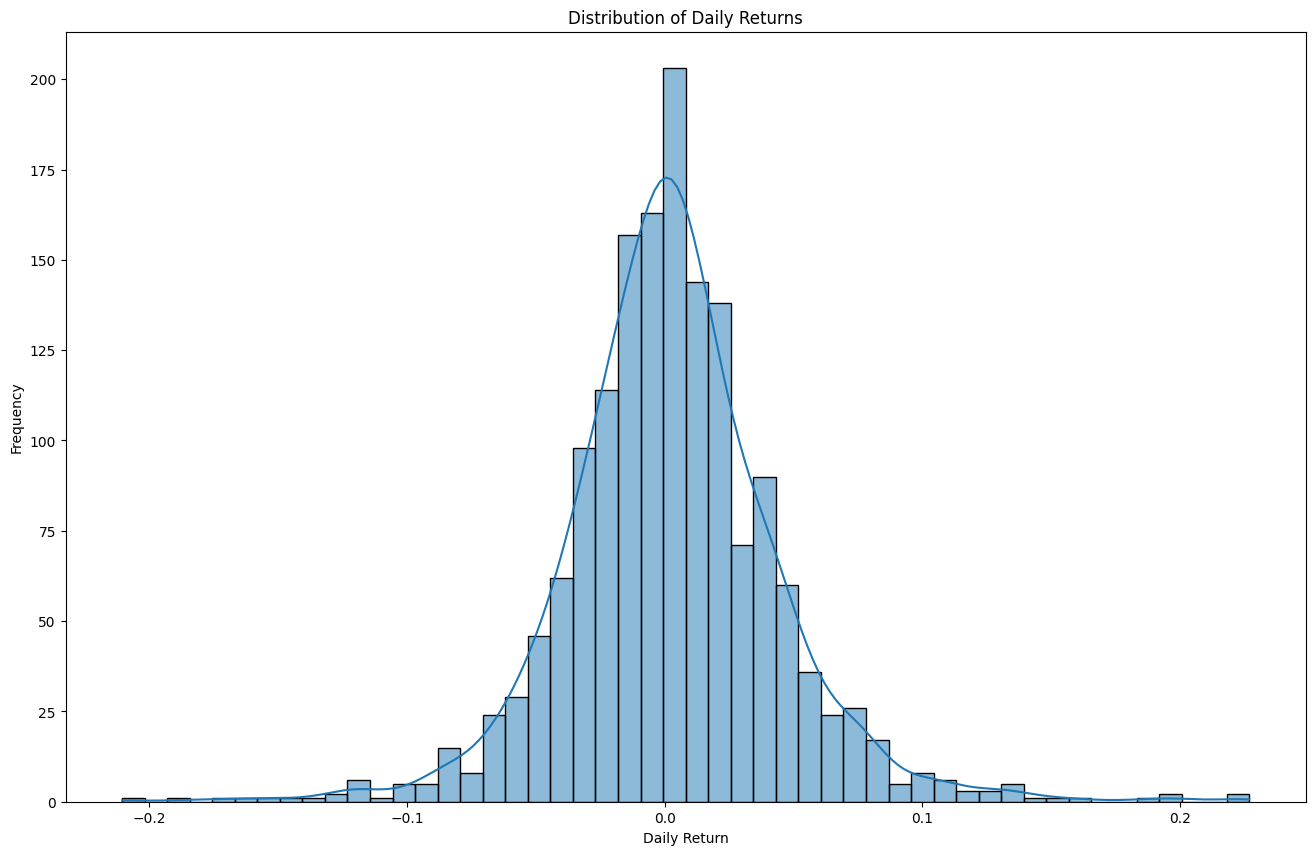

In [50]:
plt.figure(figsize=(16,10))

sns.histplot(
    x=df['Daily Return'],
    kde = True,
    bins = 50
)

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency'
)

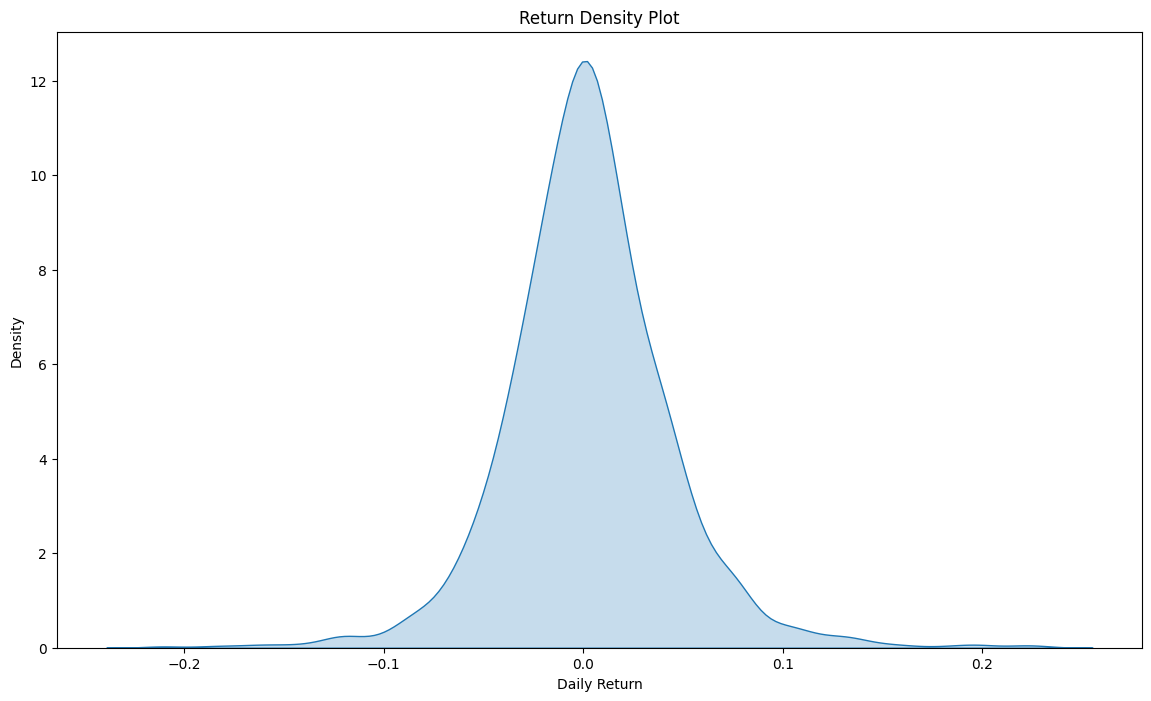

In [51]:
plt.figure(figsize=(14,8))

sns.kdeplot(
    df['Daily Return'],
    fill = True
)

plt.title('Return Density Plot')
plt.show()

In [52]:
df['Volatility'] = (
    df['Daily Return'].rolling(30).std()
)

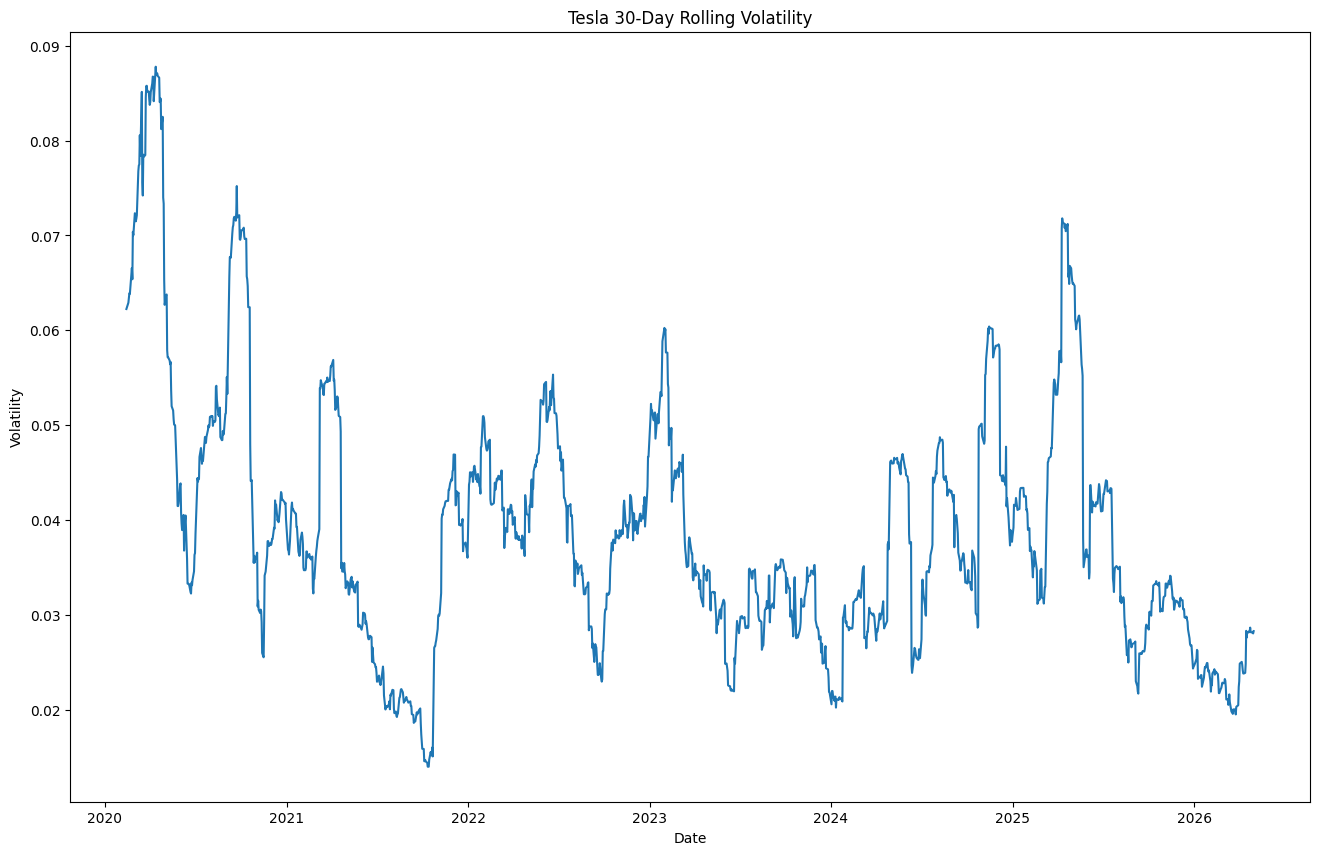

In [53]:
plt.figure(figsize=(16,10))

sns.lineplot(
    x = df.index,
    y = df['Volatility'].squeeze()
)

plt.title('Tesla 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [54]:
stocks = ['TSLA', 'MSFT', 'NVDA', 'GOOGL']

prices = yf.download(
    stocks,
    start='2020-01-01'
)['Close']

returns = prices.pct_change()

[*********************100%***********************]  4 of 4 completed


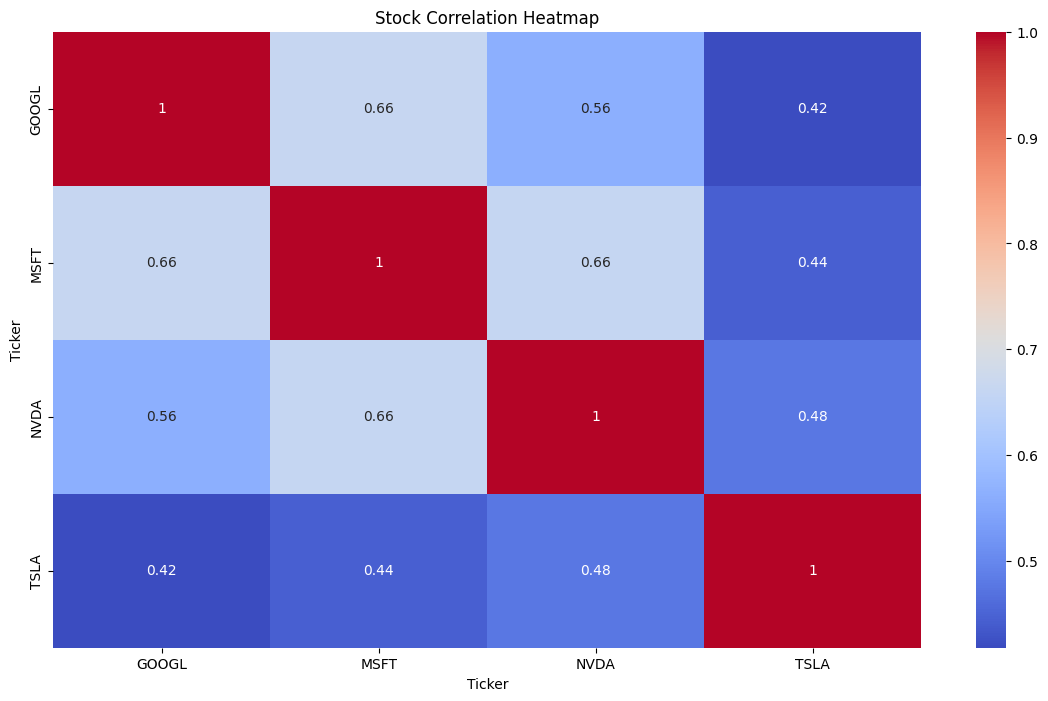

In [55]:
plt.figure(figsize=(14,8))

sns.heatmap(
    returns.corr(),
    annot = True,
    cmap = 'coolwarm'
)

plt.title('Stock Correlation Heatmap')
plt.show()

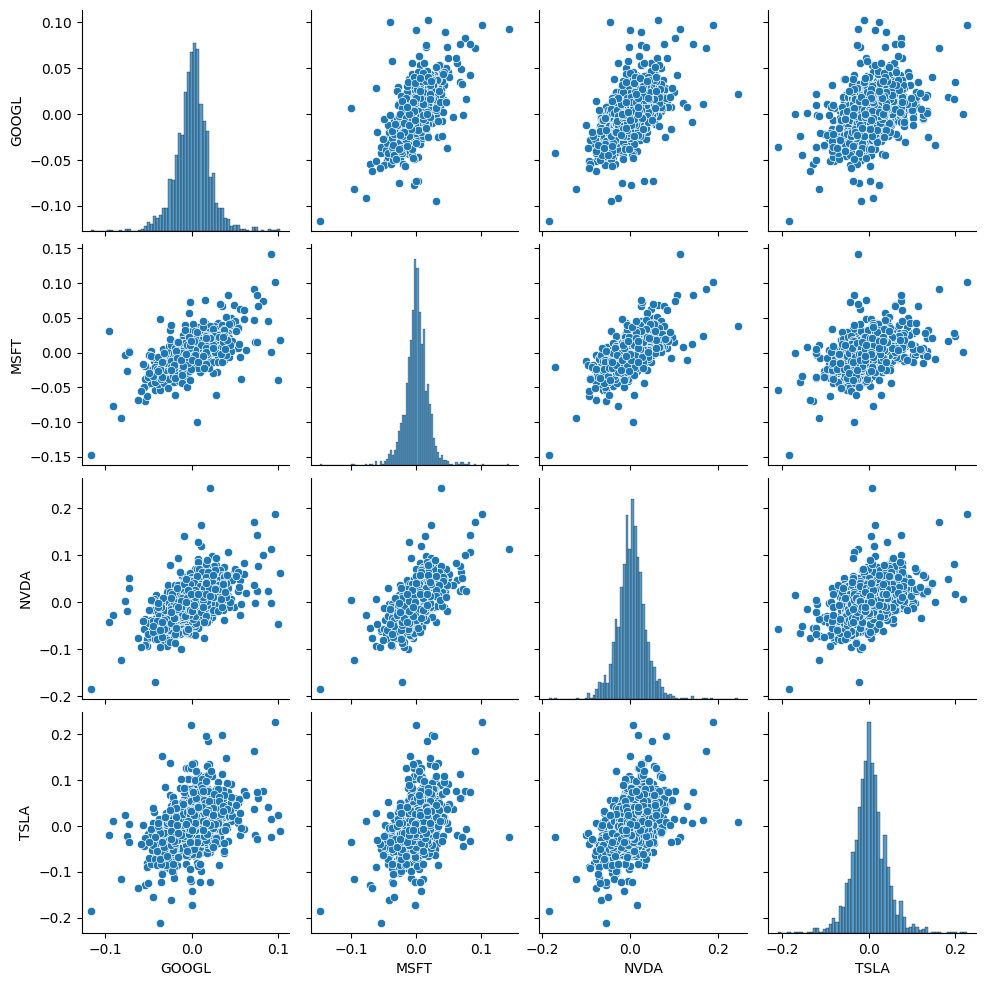

In [56]:
sns.pairplot(
    returns.dropna()
)
plt.show()

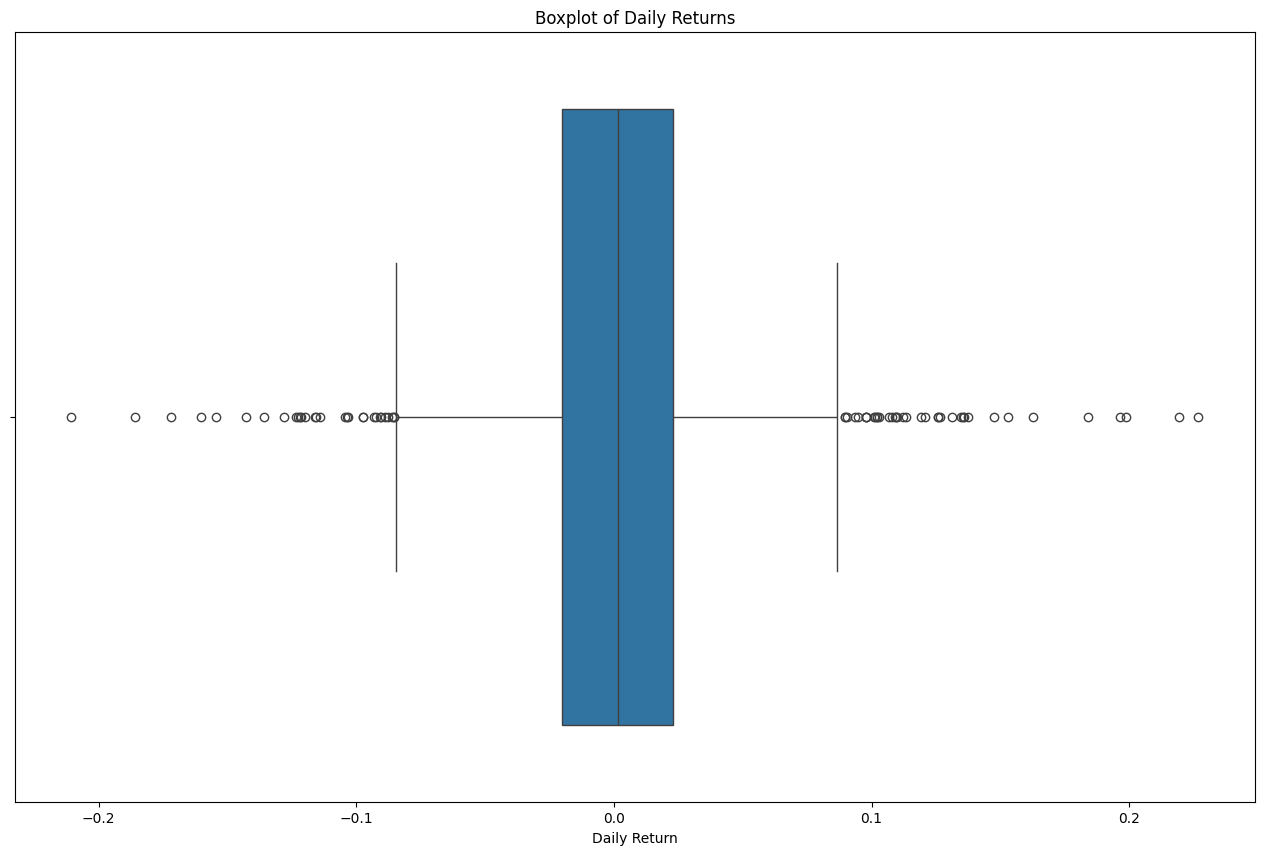

In [57]:
plt.figure(figsize=(16,10))

sns.boxplot(
    x = df['Daily Return']
)

plt.title('Boxplot of Daily Returns')
plt.show()

In [58]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

(1590, 7)
Price           Close       High        Low  ...     Volume Daily Return Volatility
Ticker           TSLA       TSLA       TSLA  ...       TSLA                        
Date                                         ...                                   
2020-01-02  28.684000  28.713333  28.114000  ...  142981500          NaN        NaN
2020-01-03  29.534000  30.266666  29.128000  ...  266677500     0.029633        NaN
2020-01-06  30.102667  30.104000  29.333332  ...  151995000     0.019255        NaN
2020-01-07  31.270666  31.441999  30.224001  ...  268231500     0.038801        NaN
2020-01-08  32.809334  33.232666  31.215334  ...  467164500     0.049205        NaN

[5 rows x 7 columns]
Price         Ticker
Close         TSLA       0
High          TSLA       0
Low           TSLA       0
Open          TSLA       0
Volume        TSLA       0
Daily Return             1
Volatility              30
dtype: int64


In [59]:
df['Lag_1'] = df['Close'].shift(1)

df['Lag_7'] = df['Close'].shift(7)

df['MA30'] = (df['Close'].rolling(30).mean())

In [60]:
df = df.dropna()

In [61]:
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'Volatility',
    'Lag_1',
    'Lag_7',
    'MA30'
]

X = df[features]

y = df['Close']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [64]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [65]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [67]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [68]:
def evaluate(y_true, pred, model):

    print(f"\n{model}")

    print(
        "MAE:",
        mean_absolute_error(y_true, pred)
    )

    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, pred))
    )

    print(
        "R2:",
        r2_score(y_true, pred)
    )

In [69]:
evaluate(y_test, lr_pred, 'Linear Regression')

evaluate(y_test, rf_pred, 'Random Forest')

evaluate(y_test, xgb_pred, 'XGBoost')


Linear Regression
MAE: 3.172619518817562
RMSE: 4.004196948909032
R2: 0.996360161643657

Random Forest
MAE: 5.256486054029918
RMSE: 6.973860848239403
R2: 0.9889592699460185

XGBoost
MAE: 6.04669713973999
RMSE: 8.389371014593872
R2: 0.9840224385261536


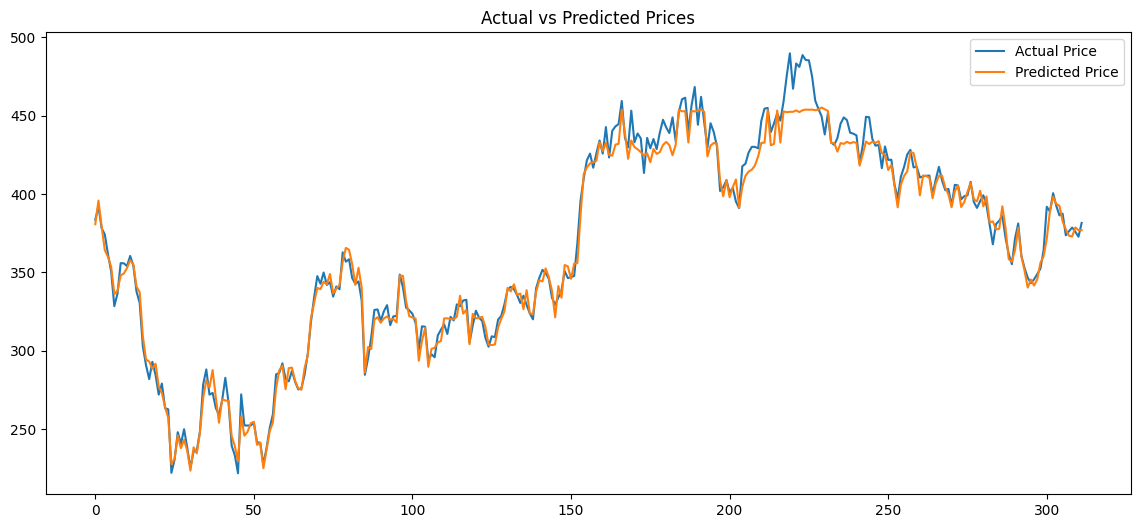

In [70]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    xgb_pred,
    label='Predicted Price'
)

plt.legend()

plt.title('Actual vs Predicted Prices')

plt.show()

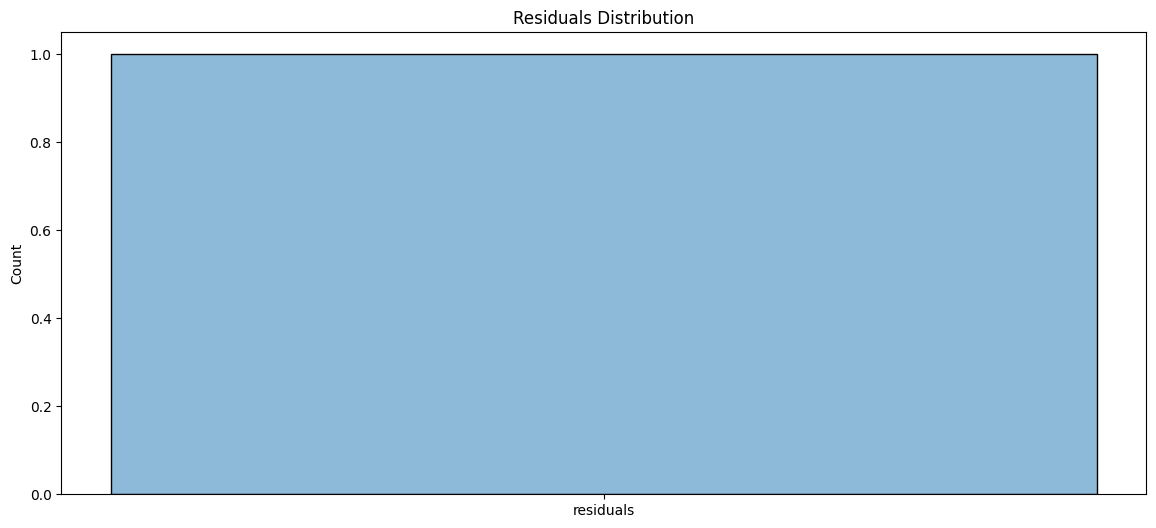

In [72]:
residuals = y_test.values - xgb_pred
plt.figure(figsize=(14,6))

sns.histplot('residuals',
             kde = True)

plt.title('Residuals Distribution')

plt.show()

In [75]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

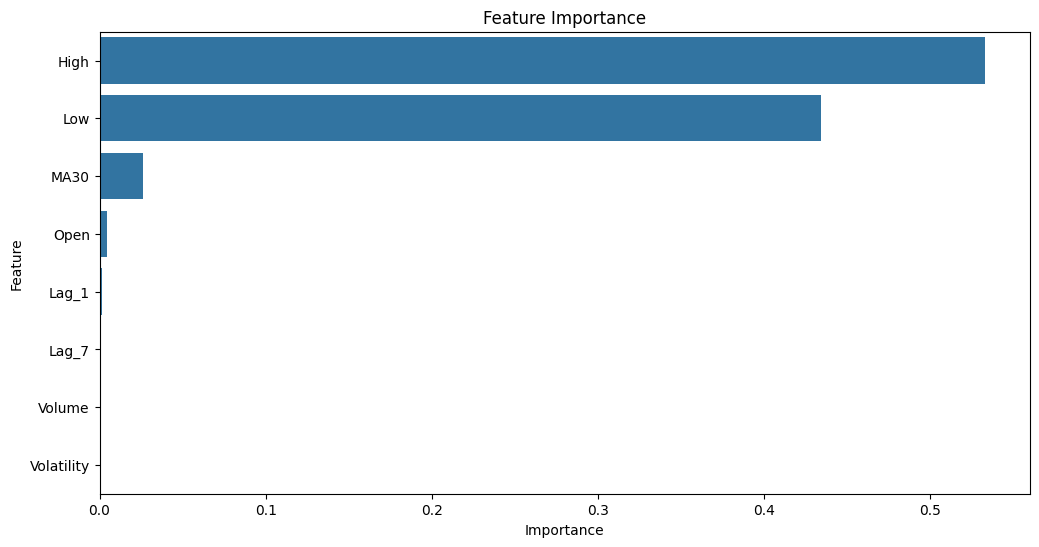

In [76]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()